In [15]:
import pandas as pd
import sqlite3 as db
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score


In [16]:

# ── 1. Population data (your existing code, unchanged) ──────────────────────
pop = pd.read_csv("county_estimates.csv", sep=";")
pop.columns = (
    pop.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)
pop["FIPS"] = pop["FIPS"].astype(str).str.zfill(5)
pop["Year"] = pd.to_datetime(pop["Year"], errors="coerce").dt.year

pop = pop[
    (pop["Area Type"] == "County") &
    (pop["Estimate"] == "Annual Estimate")
][["FIPS", "Area", "Year", "value"]].rename(columns={"value": "population"})

# ── 2. Crash data (your existing code, unchanged) ───────────────────────────
try:
    tr = pd.read_csv("nc_transportation_line_all_data.csv")
except UnicodeDecodeError:
    tr = pd.read_csv("nc_transportation_line_all_data.csv", encoding="utf-16")
tr["Geo_ID"] = tr["Geo_ID"].astype(str).str.zfill(5)

crashes = tr[
    (tr["Variable"] == "Traffic Accidents")
][["Geo_ID", "Area_Name", "Year", "Value"]].rename(
    columns={"Geo_ID": "FIPS", "Value": "crashes"}
)

# ── 3. NEW: Load and pivot the LINC formatted file ──────────────────────────
linc = pd.read_csv("nc-transportation-linc-formatted.csv")
linc["Geo_ID"] = linc["Geo_ID"].astype(str).str.zfill(5)

# Filter to Mecklenburg only, then pivot long → wide
linc_meck = linc[linc["Geo_ID"] == "37119"].copy()

linc_wide = linc_meck.pivot_table(
    index=["Geo_ID", "Year"],
    columns="Variable",
    values="Value",
    aggfunc="first"
).reset_index().rename(columns={"Geo_ID": "FIPS"})

# Flatten column names (removes the "Variable" label from the MultiIndex)
linc_wide.columns.name = None

# ── 4. Merge everything together ─────────────────────────────────────────────
merged = crashes.merge(pop, on=["FIPS", "Year"], how="inner")
merged = merged.merge(linc_wide, on=["FIPS", "Year"], how="inner")

# ── 5. Filter to Mecklenburg, deduplicate, sort (your existing logic) ────────
df = merged[merged["FIPS"] == "37119"].copy()
df = df.sort_values("Year").drop_duplicates(subset=["Year"])

# ── 6. Growth variables (your existing code, unchanged) ──────────────────────
df["pop_change"] = df["population"].diff()
df["pop_growth_pct"] = df["population"].pct_change() * 100
df["crash_growth_pct"] = df["crashes"].pct_change() * 100

# ── 7. Per-capita normalization of key LINC features ────────────────────────
per_capita_vars = [
    "Traffic Accident Fatalities",
    "Alcohol Related Accidents",
    "Accidents Caused by Exceeding Legal Speed",
    "Motorcyclists Injured",
    "Motorcyclist Fatalities",
    "Pedestrian Accidents",
    "Pedestrians Injured",
    "Bicyclists Injured",
]
for var in per_capita_vars:
    if var in df.columns:
        df[f"{var}_per_capita"] = df[var] / df["population"] * 100_000

# ── 8. Create binary target label ────────────────────────────────────────────
median_fatalities = df["Traffic Accident Fatalities"].median()
df["high_fatality"] = (df["Traffic Accident Fatalities"] > median_fatalities).astype(int)

print(f"Median fatalities: {median_fatalities}")
print(f"Label distribution:\n{df['high_fatality'].value_counts()}")
print(f"\nFinal dataset shape: {df.shape}")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")

Median fatalities: 74.0
Label distribution:
high_fatality
1    22
0    22
Name: count, dtype: int64

Final dataset shape: (44, 38)
Year range: 1975 – 2024


CLASSIFICATION MODEL — SETUP
Features used       : 5
Modeling rows       : 43
Year range          : 1981 – 2024
Label distribution  : {0: np.int64(22), 1: np.int64(21)}

MODEL RESULTS

── Logistic Regression (C=0.1, scaled) ──────────
  Accuracy : 0.608 ± 0.143
  F1       : 0.604 ± 0.139
  ROC-AUC  : 0.615 ± 0.146

  Coefficients (sorted by magnitude):
    Accidents Caused by Exceeding Legal Speed_per_capita -0.1650
    Alcohol Related Accidents_per_capita               -0.1008
    Motorcyclists Injured_per_capita                   -0.0497
    pop_growth_pct                                     +0.0273
    Bicyclists Injured_per_capita                      +0.0181

── Random Forest (depth=3, min_leaf=3, n=300) ───
  Accuracy : 0.678 ± 0.107
  F1       : 0.672 ± 0.100
  ROC-AUC  : 0.675 ± 0.108

  Feature Importances (Gini):
    Accidents Caused by Exceeding Legal Speed_per_capita 0.2779
    Alcohol Related Accidents_per_capita               0.2557
    Motorcyclists Injured_per_capita   

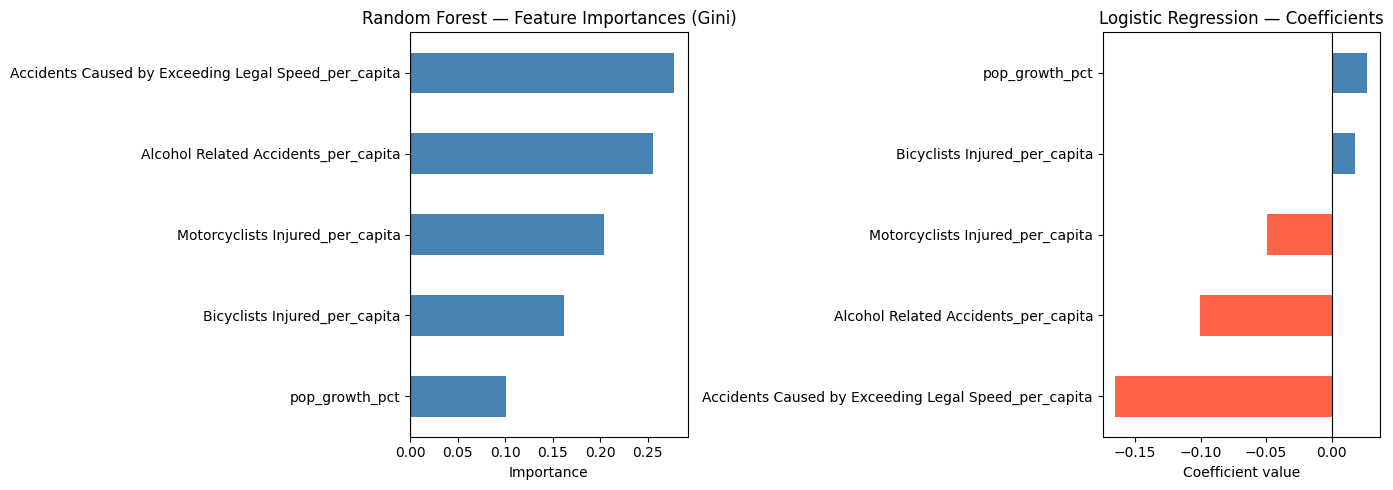


Plot saved to classification_feature_importance.png


In [17]:

# ── 1. Feature Selection ─────────────────────────────────────────────────────
feature_cols = [
    "Alcohol Related Accidents_per_capita",
    "Accidents Caused by Exceeding Legal Speed_per_capita",
    "Motorcyclists Injured_per_capita",
    "Bicyclists Injured_per_capita",
    "pop_growth_pct",
]
feature_cols = [c for c in feature_cols if c in df.columns]

# ── 2. Build Modeling Dataset ────────────────────────────────────────────────
model_df = df[feature_cols + ["high_fatality", "Year"]].dropna().copy()
X = model_df[feature_cols].values
y = model_df["high_fatality"].values

print("=" * 55)
print("CLASSIFICATION MODEL — SETUP")
print("=" * 55)
print(f"Features used       : {len(feature_cols)}")
print(f"Modeling rows       : {len(model_df)}")
print(f"Year range          : {model_df['Year'].min()} – {model_df['Year'].max()}")
print(f"Label distribution  : {dict(pd.Series(y).value_counts().sort_index())}")

# ── 3. Cross-Validation Setup ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy" : make_scorer(accuracy_score),
    "f1"       : make_scorer(f1_score),
    "roc_auc"  : make_scorer(roc_auc_score),
}

def print_scores(name, scores):
    print(f"\n── {name} {'─' * (45 - len(name))}")
    print(f"  Accuracy : {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"  F1       : {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"  ROC-AUC  : {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")

# ── 4. Model 1: Logistic Regression ─────────────────────────────────────────
# C=0.1 applies stronger regularization — important for small datasets
# StandardScaler required so coefficients are on the same scale
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, C=0.1, random_state=42))
])
lr_scores = cross_validate(lr_pipe, X, y, cv=cv, scoring=scorers)

print("\n" + "=" * 55)
print("MODEL RESULTS")
print("=" * 55)
print_scores("Logistic Regression (C=0.1, scaled)", lr_scores)

# Fit on full data for coefficients
lr_pipe.fit(X, y)
lr_coefs = pd.Series(
    lr_pipe.named_steps["clf"].coef_[0],
    index=feature_cols
).sort_values(key=abs, ascending=False)
print("\n  Coefficients (sorted by magnitude):")
for feat, coef in lr_coefs.items():
    print(f"    {feat:<50} {coef:+.4f}")

# ── 5. Model 2: Random Forest ────────────────────────────────────────────────
# max_depth=3 keeps trees shallow to avoid overfitting on 44 rows
# min_samples_leaf=3 prevents splits on tiny groups
rf_pipe = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ))
])
rf_scores = cross_validate(rf_pipe, X, y, cv=cv, scoring=scorers)
print_scores("Random Forest (depth=3, min_leaf=3, n=300)", rf_scores)

# Fit on full data for feature importances
rf_pipe.fit(X, y)
rf_importances = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)
print("\n  Feature Importances (Gini):")
for feat, imp in rf_importances.items():
    print(f"    {feat:<50} {imp:.4f}")

# ── 6. Model 3: K-Nearest Neighbors ─────────────────────────────────────────
# k=7 — odd number avoids ties, ~sqrt(44) is a common heuristic for small N
# StandardScaler critical for KNN — distance-based, scale-sensitive
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7, metric="euclidean"))
])
knn_scores = cross_validate(knn_pipe, X, y, cv=cv, scoring=scorers)
print_scores("KNN (k=7, euclidean, scaled)", knn_scores)

# ── 7. Summary Comparison Table ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("SUMMARY COMPARISON")
print("=" * 55)
print(f"{'Model':<42} {'Accuracy':>9} {'F1':>7} {'ROC-AUC':>9}")
print("-" * 55)
for name, scores in [
    ("Logistic Regression", lr_scores),
    ("Random Forest",       rf_scores),
    ("KNN (k=7)",           knn_scores),
]:
    acc = scores['test_accuracy'].mean()
    f1  = scores['test_f1'].mean()
    auc = scores['test_roc_auc'].mean()
    print(f"  {name:<40} {acc:.3f}     {f1:.3f}   {auc:.3f}")

# ── 8. Feature Importance Plot (Random Forest) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF importances
rf_importances.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest — Feature Importances (Gini)")
axes[0].set_xlabel("Importance")
axes[0].axvline(0, color="black", linewidth=0.8)

# LR coefficients
lr_coefs.sort_values().plot(kind="barh", ax=axes[1], color=["tomato" if c < 0 else "steelblue" for c in lr_coefs.sort_values()])
axes[1].set_title("Logistic Regression — Coefficients")
axes[1].set_xlabel("Coefficient value")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("classification_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to classification_feature_importance.png")